# Exploratory Data Analysis


In [1]:
# =============================================================================
# 01_EDA — Exploratory Data Analysis
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")



In [2]:
df = pd.read_csv("../data/raw/data_modelo.csv", encoding="latin-1")
df.head()

,ID,TARGET,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,BASE
0,6290921,7666,344499.0,1124.0,2509,-9999998,NaN,3.0,811.0,3,SURQUILLO,18300,95.0,27.0,TRAIN
1,621369,6062,98183.0,2664.0,2847,387252,181615.0,2.0,776.0,2,LA VICTORIA,272883,115.0,56.0,TRAIN
2,218437,6977,505263.0,4790.0,10308,6056,1886.0,4.0,643.0,2,MOYOBAMBA,181967,94.0,48.0,TRAIN
3,3089628,4122,207137.0,6427.0,1974,-9999998,NaN,1.0,633.0,1,TARAPOTO,30170,146.0,47.0,TRAIN
4,2351873,7742,154331.0,803.0,7630,6991,3222.0,1.0,854.0,1,SAN MARTIN DE PORRES,29045,40.0,33.0,TRAIN


In [3]:
df.describe().apply(lambda s: s.apply('{0:.2f}'.format))


,ID,TARGET,X1,X2,X3,X4,X5,X6,X7,X8,X10,X11,X12
count,50001.00,50001.00,49215.00,45008.00,50001.00,50001.00,33603.00,50000.00,49450.00,50001.00,50001.00,48281.00,48281.00
mean,2709827.03,8425.21,340688.59,4128.43,-3977994.03,-2901145.11,93087.07,1.85,773.64,1.72,70021.53,-8439739.87,-1381999.80
std,2227479.57,5935.40,487098.69,9538.43,4901020.39,4721780.08,790101.19,1.06,131.63,4.54,74778.42,27646751.82,11615354.49
min,9.00,1000.00,0.00,55.00,-9999998.00,-9999998.00,0.00,1.00,0.00,1.00,0.00,-99000720.00,-99000792.00
25%,1084482.00,4618.00,75399.50,1160.00,-9999998.00,-9999998.00,1789.50,1.00,755.00,1.00,9142.00,57.00,37.00
50%,2182781.00,6966.00,220416.00,2443.50,1173.00,11556.00,11668.00,2.00,812.00,2.00,48464.00,95.00,44.00
75%,3482249.00,10445.00,437720.50,4266.00,5092.00,77370.00,75106.50,2.00,840.00,2.00,107400.00,149.00,53.00
max,20594239.00,40000.00,25398122.00,775572.00,1342785.00,133648783.00,113159600.00,4.00,995.00,999.00,751904.00,3600.00,98.00


In [4]:
# ── Missing values (including sentinel) ───────────────────────────────────
missing = pd.DataFrame({
    "nulls":     df.isnull().sum(),
    "total":     df.isnull().sum(),
    "pct":       (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values("total", ascending=False)

missing[missing["total"] > 0]

,nulls,total,pct
X5,16398,16398,32.80
X2,4993,4993,9.99
X11,1720,1720,3.44
X12,1720,1720,3.44
X9,912,912,1.82
X1,786,786,1.57
X7,551,551,1.10
X6,1,1,0.00


In [5]:
def plot_distribution(df, column):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"Distribution of {column}", fontsize=13)
    
    # Stats table
    stats = df[column].describe().round(2)
    nulls = df[column].isnull().sum()
    null_pct = (nulls / len(df) * 100).round(2)
    stats["nulls"] = nulls
    stats["null_%"] = null_pct
    
    axes[0].axis("off")
    table = axes[0].table(
        cellText=[[v] for v in stats.values],
        rowLabels=stats.index,
        colLabels=["value"],
        loc="center",
        cellLoc="center"
    )
    table.scale(1, 1.4)
    axes[0].set_title("Summary Stats")

    df[column].hist(bins=50, ax=axes[1], edgecolor="none")
    axes[1].set_title("Histogram")

    df[column].plot.box(ax=axes[2])
    axes[2].set_title("Boxplot")

    plt.tight_layout()
    plt.show()

## Distribution of target and numeric features

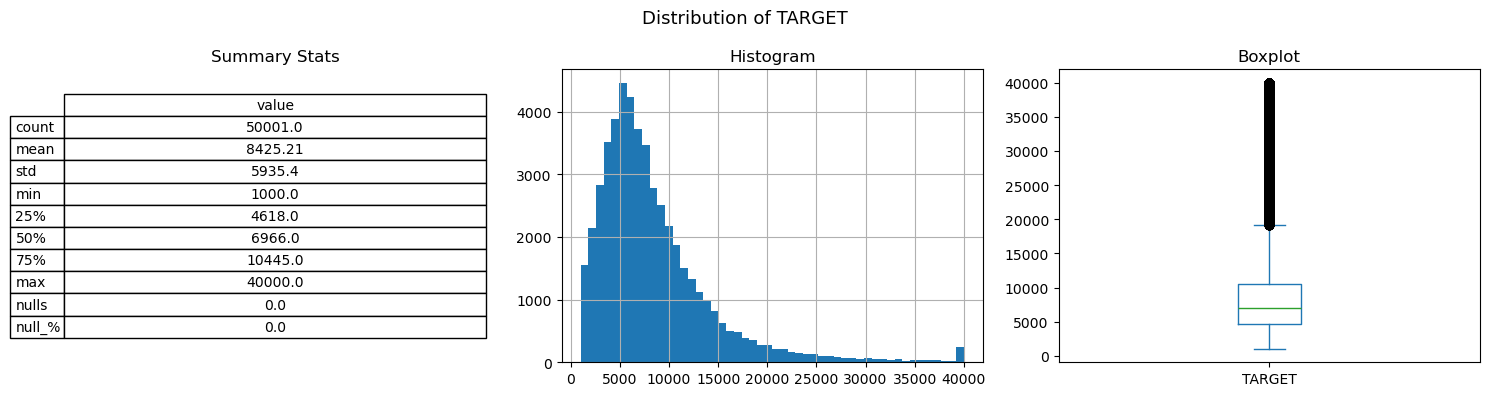

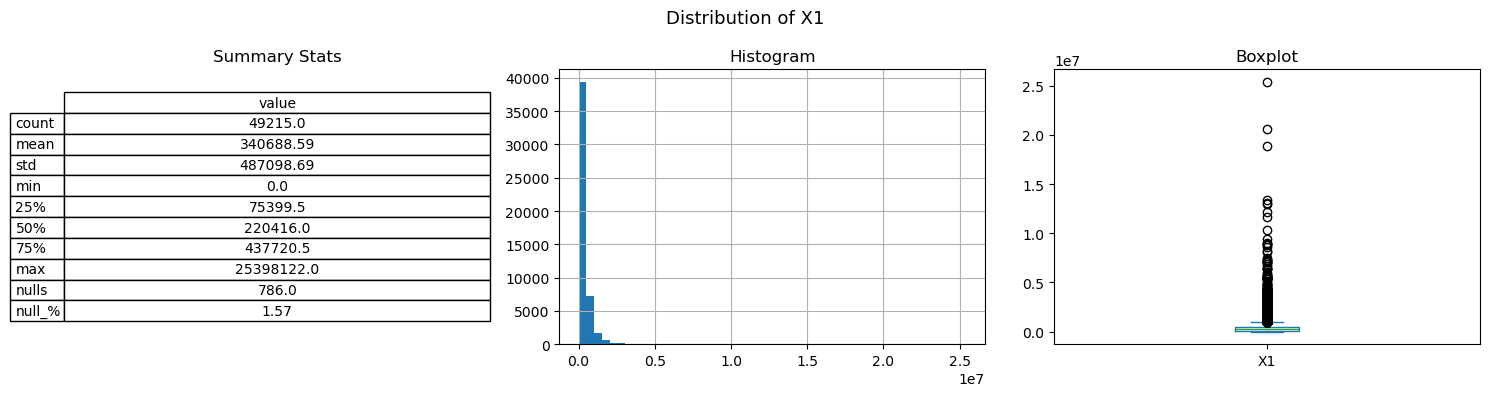

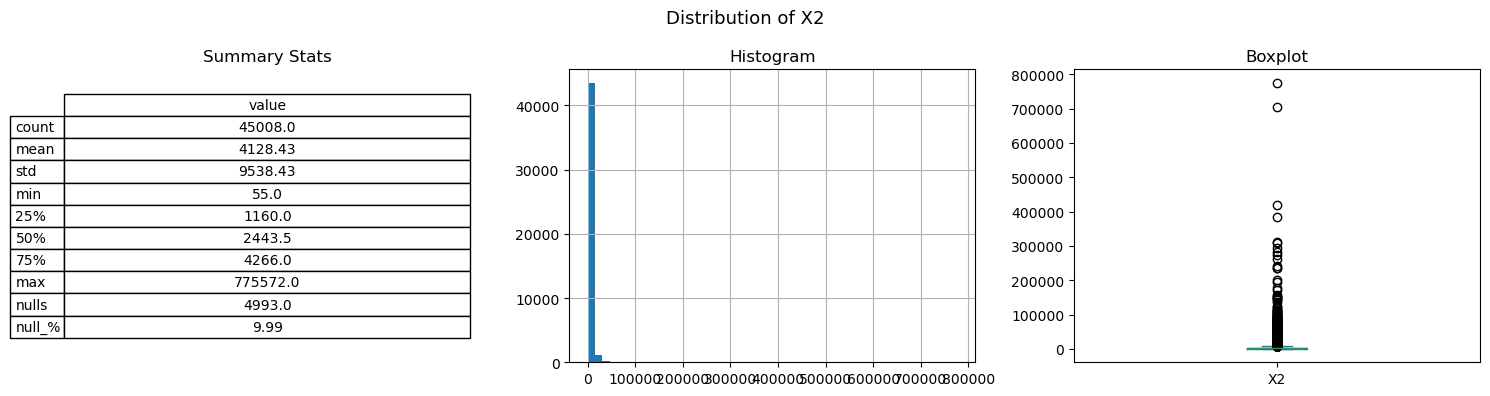

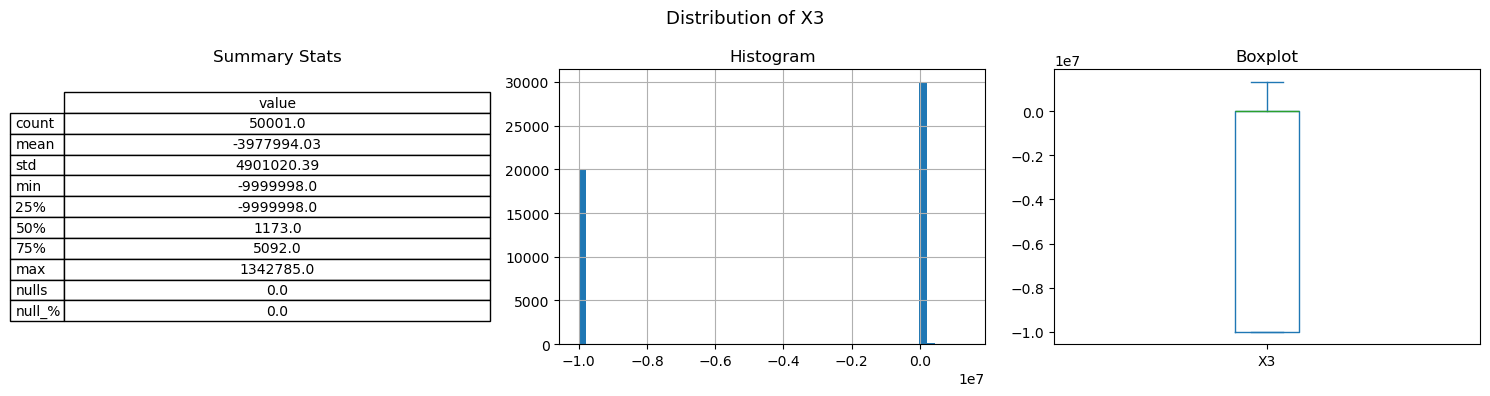

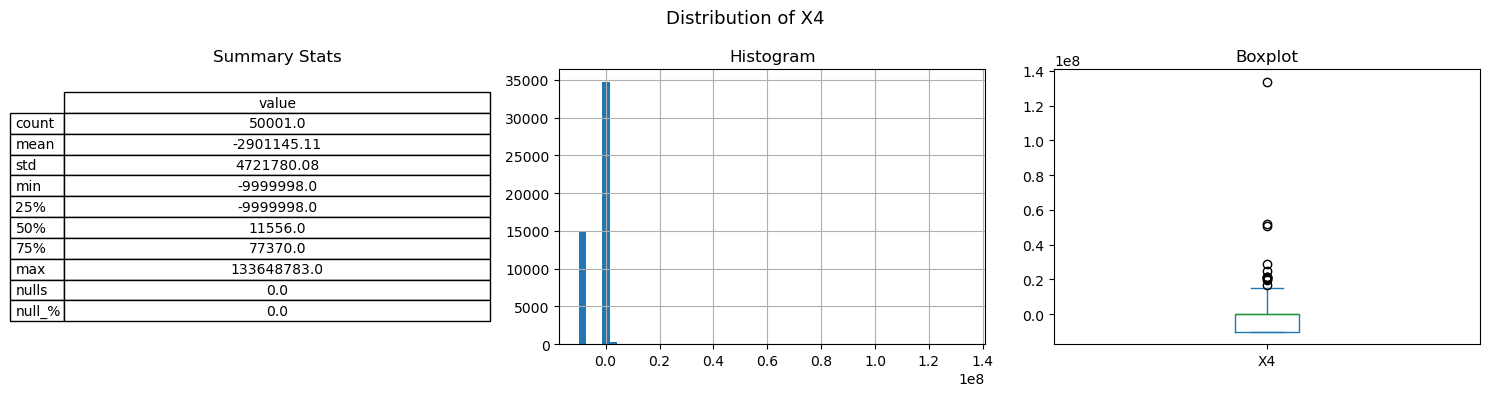

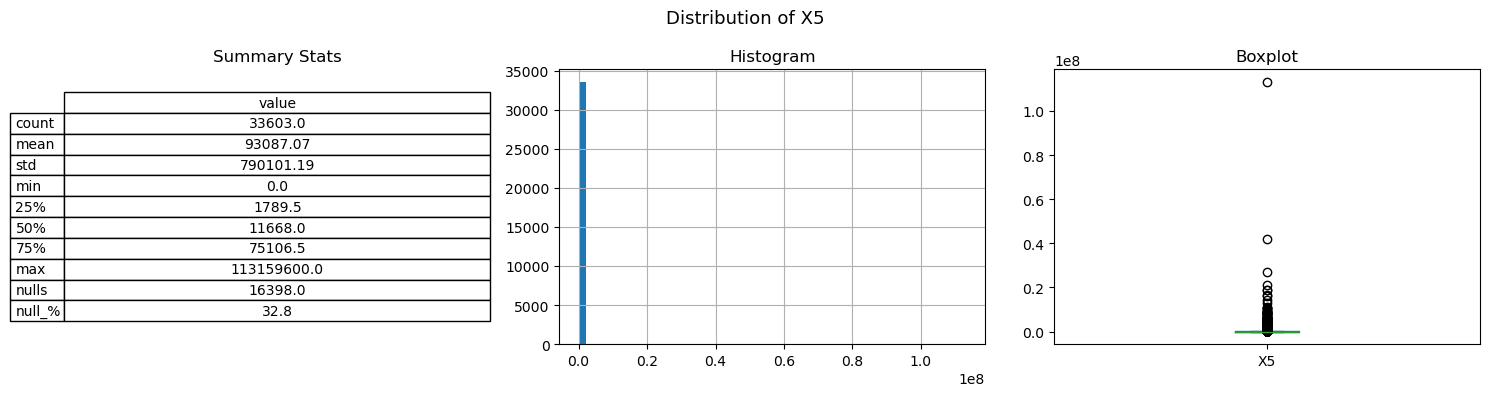

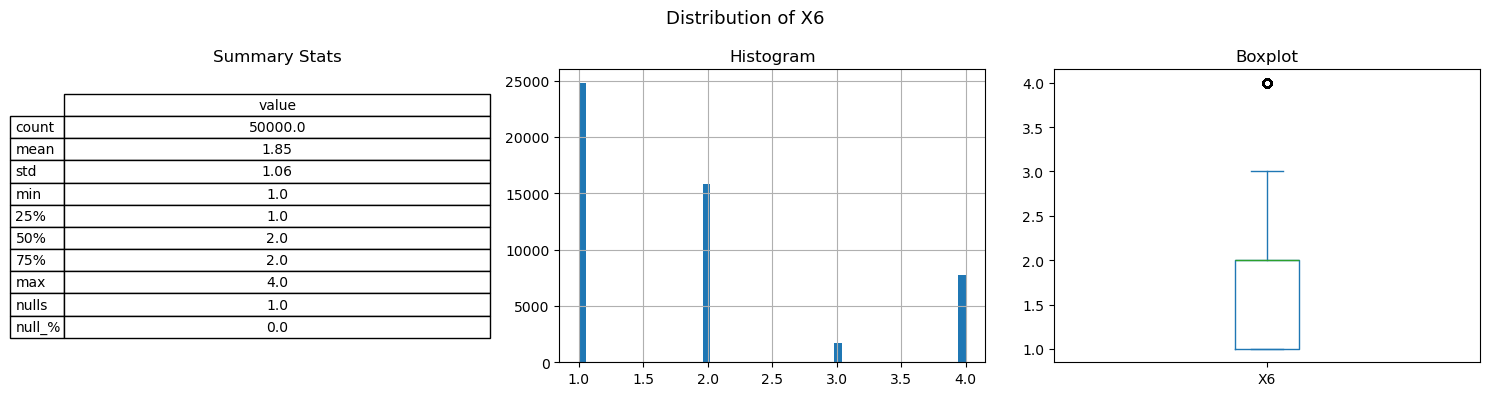

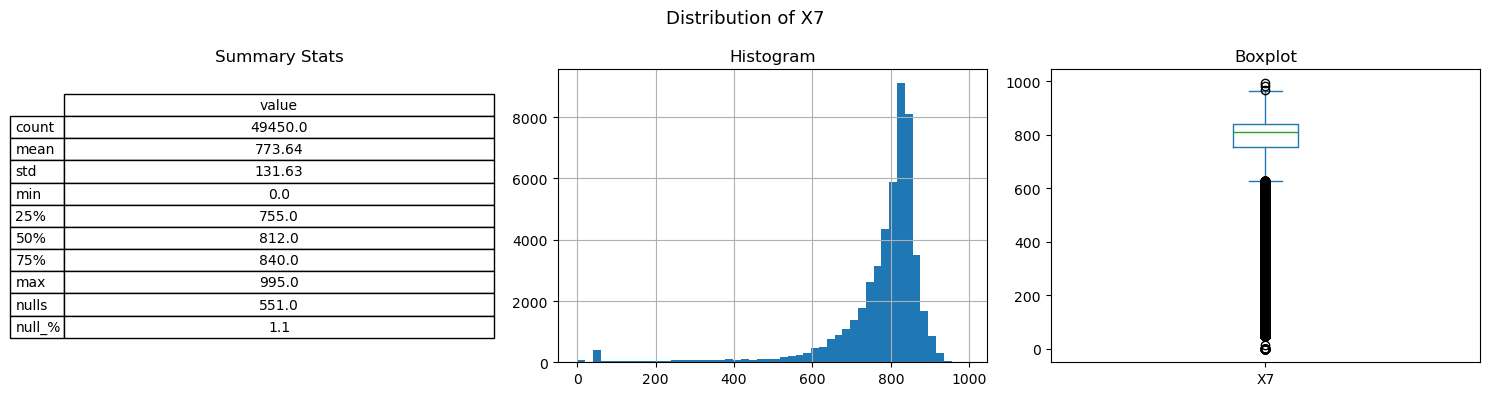

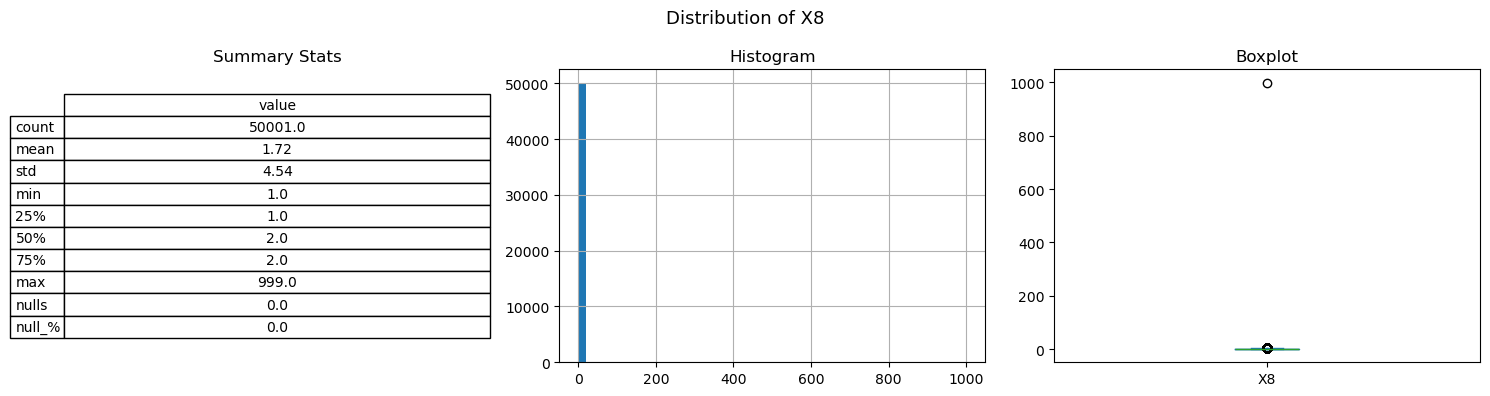

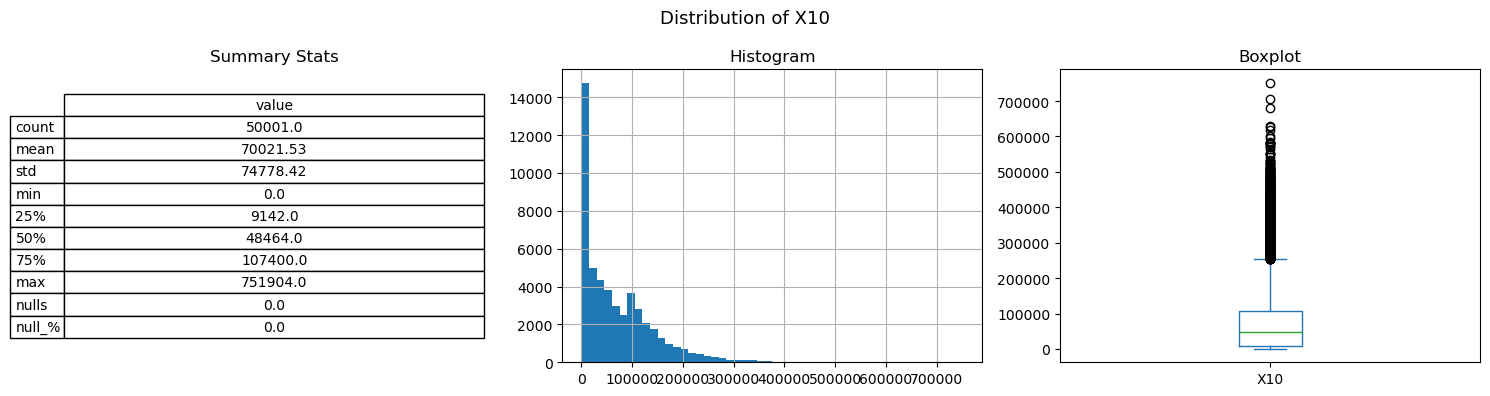

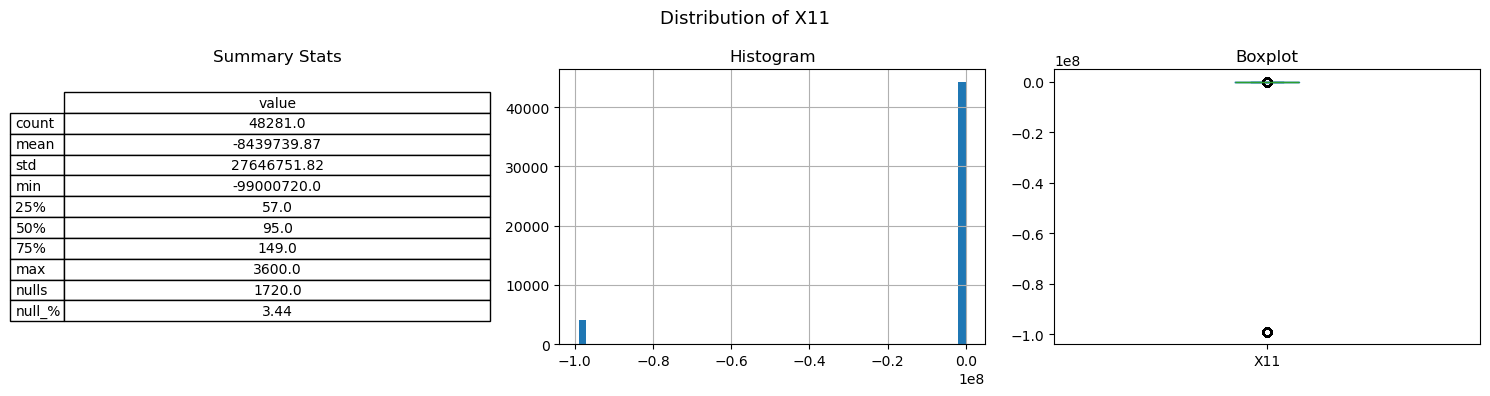

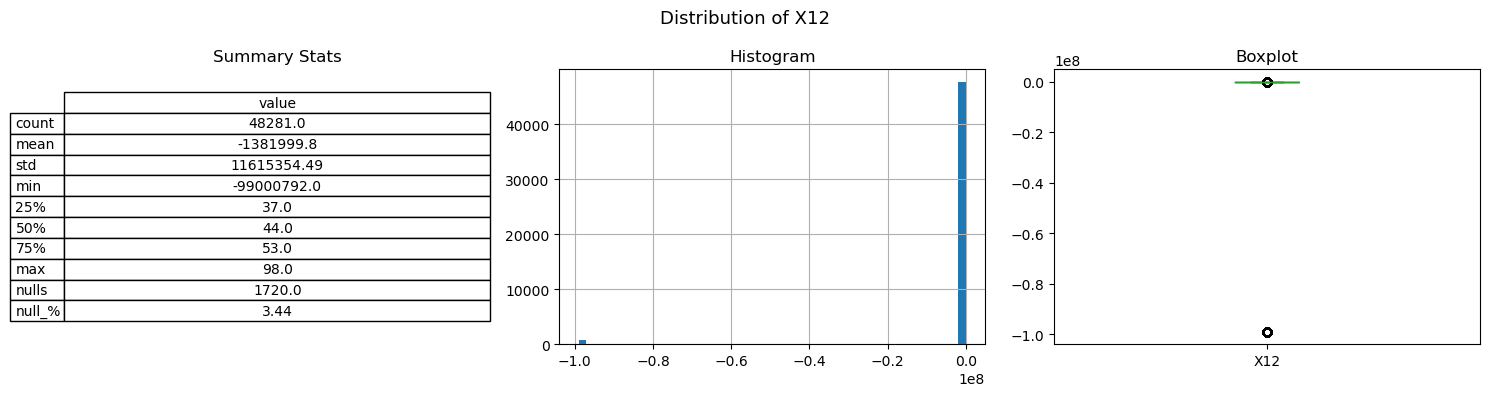

In [6]:
columns = ["TARGET", "X1", "X2", "X3", "X4", "X5", "X6", "X7", "X8", "X10", "X11", "X12"]
for col in columns:
    plot_distribution(df, col)

## Entendimiento de valores sentinel

In [7]:
SENTINELS = {
    "X3":  [-9999998],
    "X4":  [-9999998],
    "X8":  [999],
    "X11": [-99000720, -99000632],
    "X12": [-99000792],
}

for col, vals in SENTINELS.items():
    for val in vals:
        count = (df[col] == val).sum()
        pct = (count / len(df) * 100).round(2)
        print(f"{col} | sentinel {val} → {count} rows ({pct}%)")

X3 | sentinel -9999998 → 19922 rows (39.84%)
X4 | sentinel -9999998 → 15007 rows (30.01%)
X8 | sentinel 999 → 1 rows (0.0%)
X11 | sentinel -99000720 → 3496 rows (6.99%)
X11 | sentinel -99000632 → 620 rows (1.24%)
X12 | sentinel -99000792 → 674 rows (1.35%)


In [8]:
# Check overlap of missing X3 and X4
both_missing = df[(df["X3"] == -9999998) & (df["X4"] == -9999998)].shape[0]
only_x3 = df[(df["X3"] == -9999998) & (df["X4"] != -9999998)].shape[0]
only_x4 = df[(df["X4"] == -9999998) & (df["X3"] != -9999998)].shape[0]

print(f"Both missing:  {both_missing}")
print(f"Only X3:       {only_x3}")
print(f"Only X4:       {only_x4}")

Both missing:  10397
Only X3:       9525
Only X4:       4610


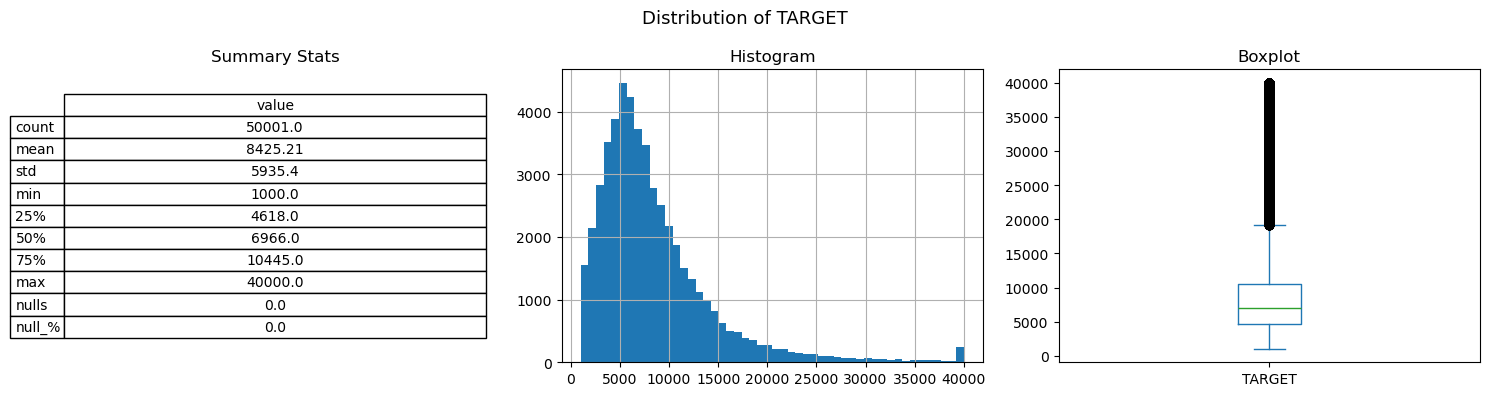

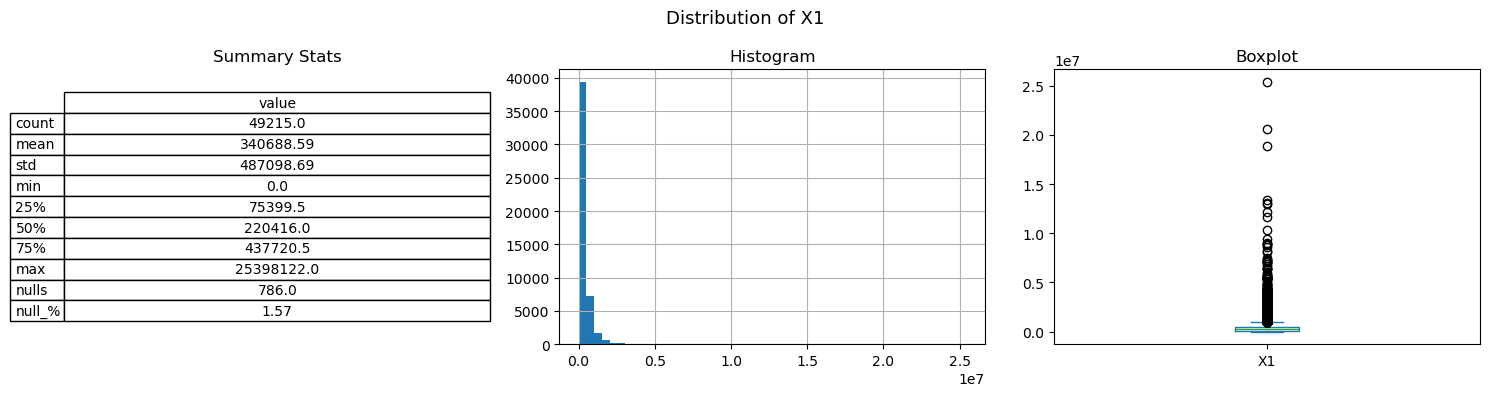

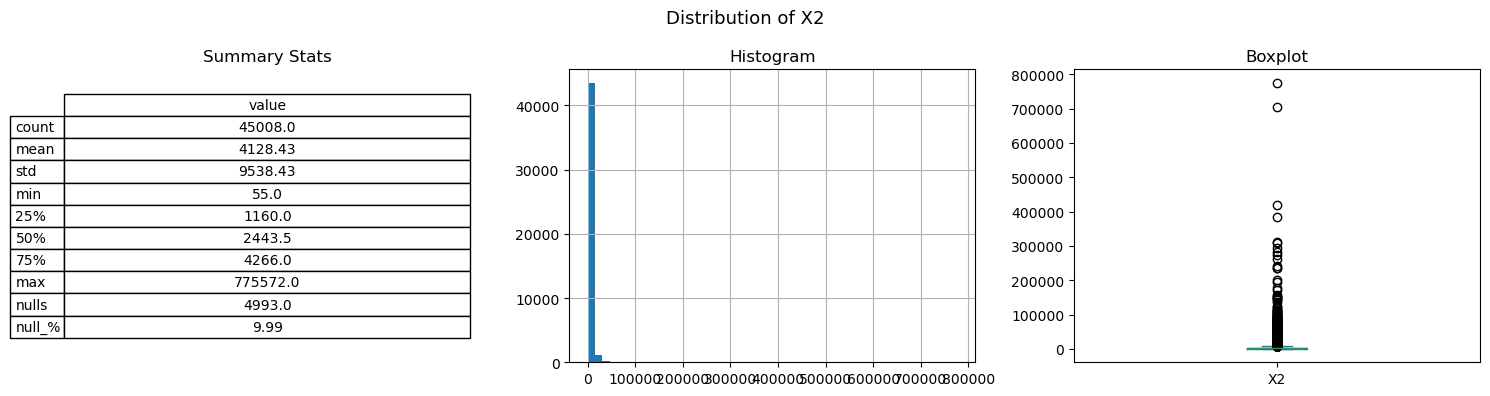

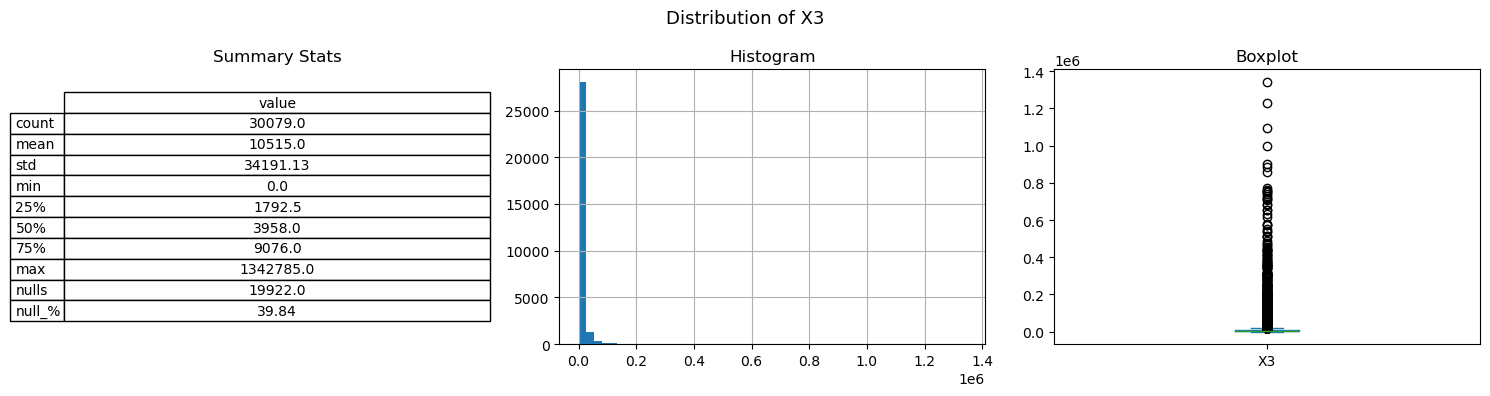

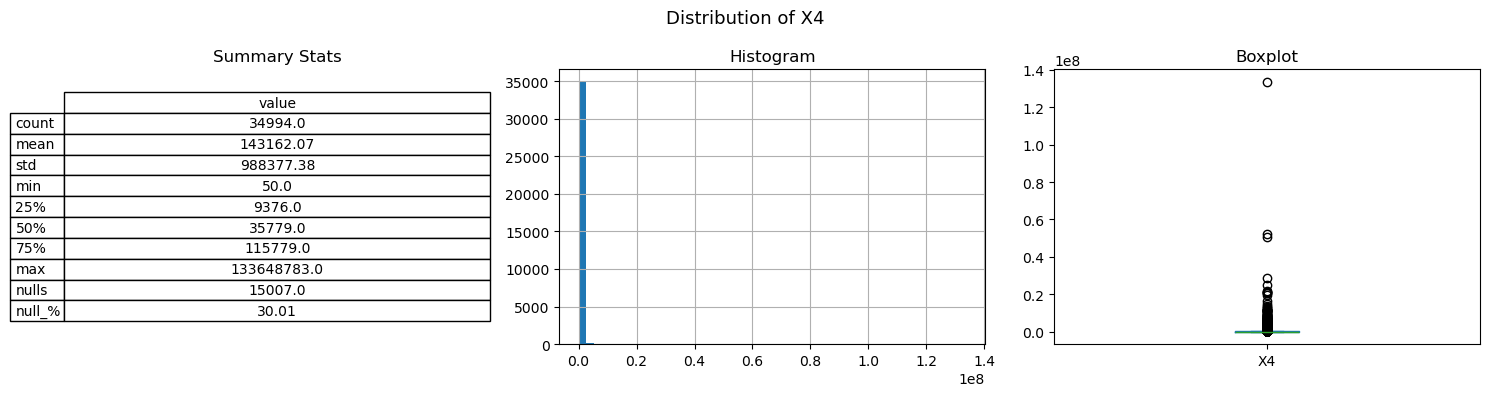

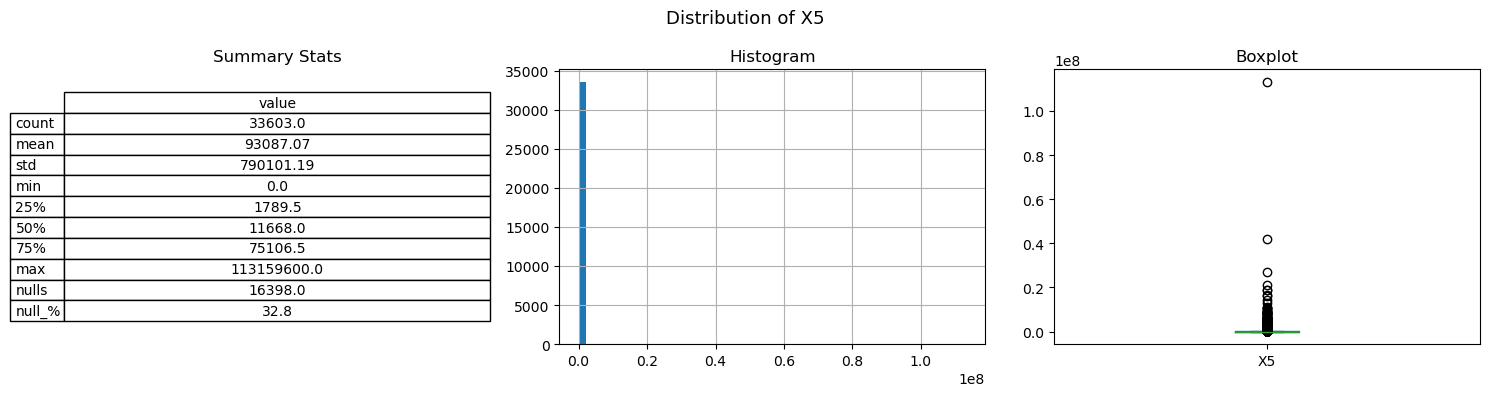

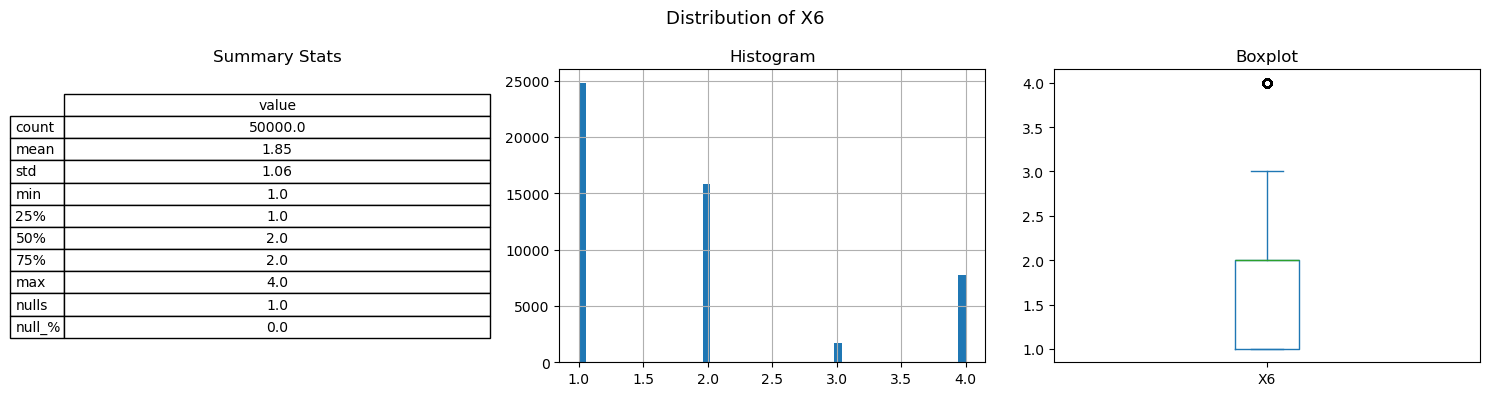

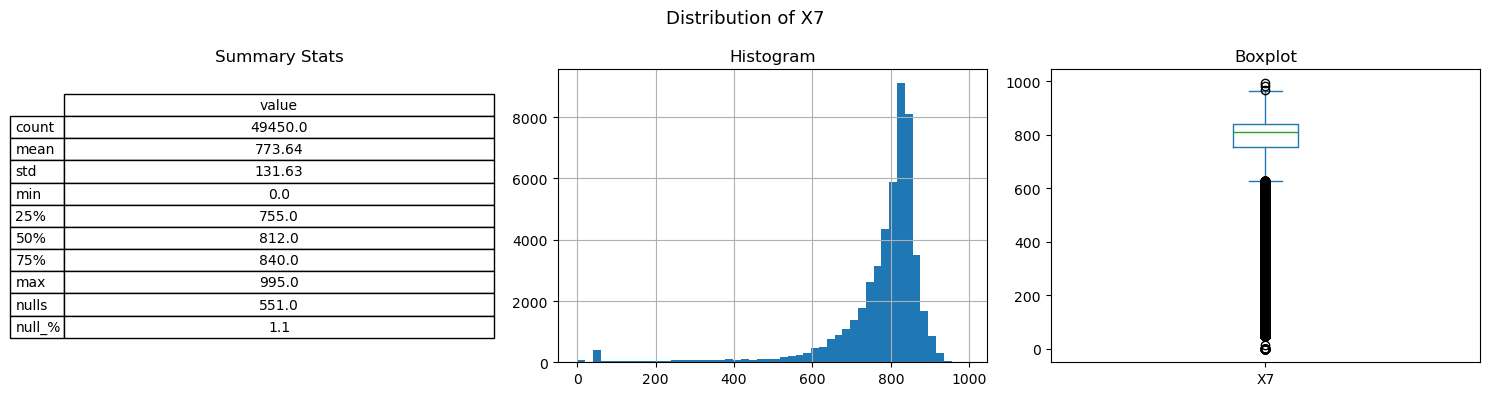

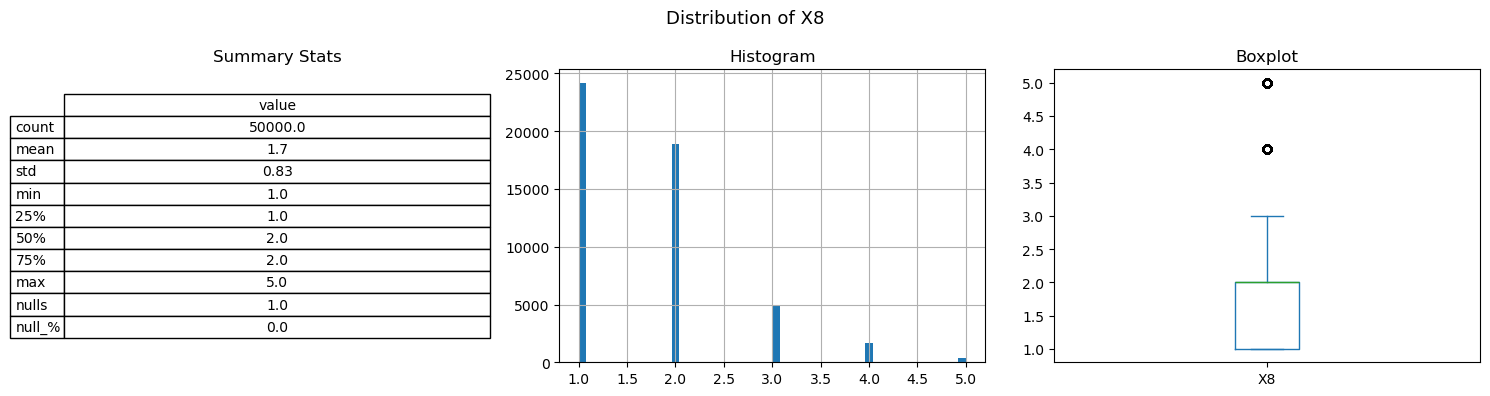

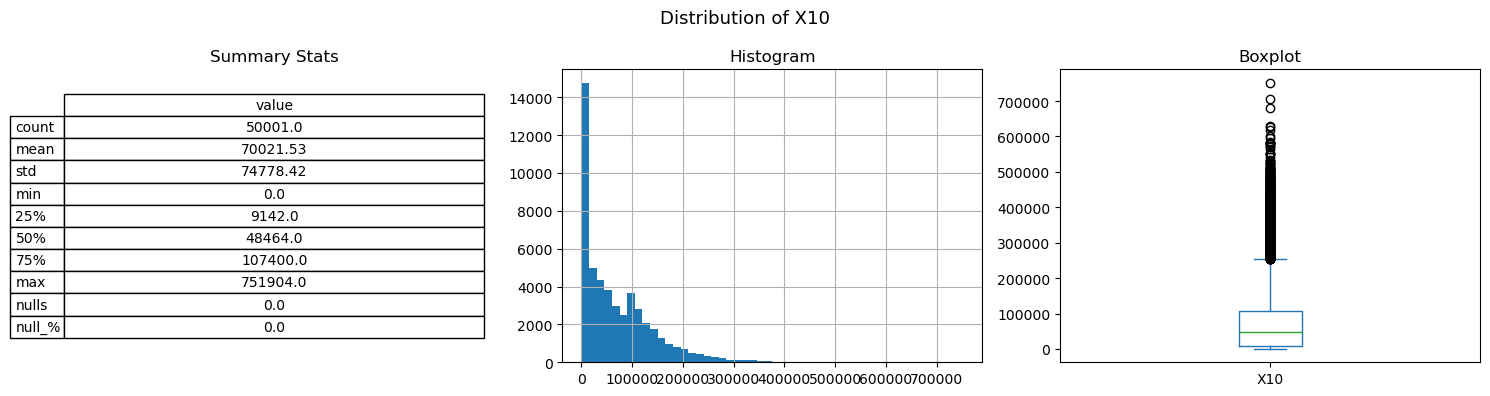

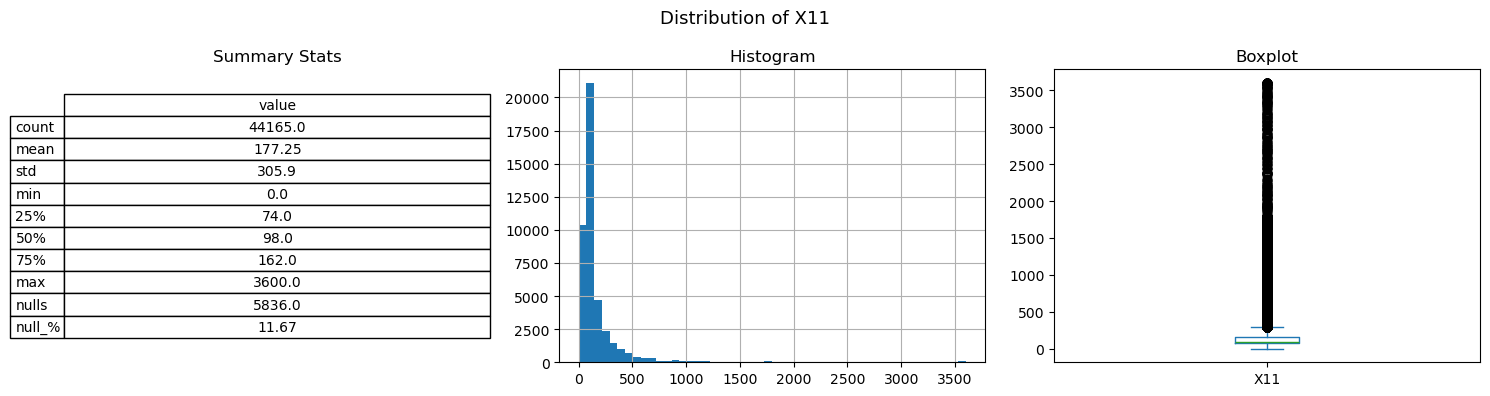

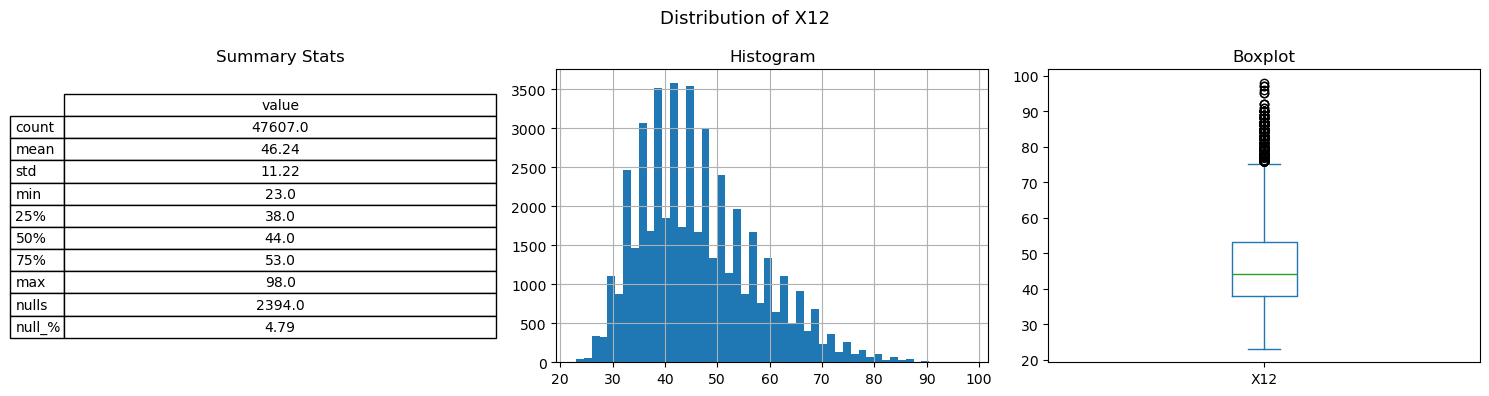

In [9]:
# Replace all sentinels with NaN
df_nosentinels = df.copy()

for col, vals in SENTINELS.items():
    for val in vals:
        df_nosentinels[col] = df_nosentinels[col].replace(val, np.nan)

# Replot
for col in columns:
    plot_distribution(df_nosentinels, col)

## Compare new missing values

In [10]:
missing = pd.DataFrame({
    "count": df.isnull().sum(),
    "pct":   (df.isnull().sum() / len(df) * 100).round(2)
})

missing[missing["count"] > 0]

,count,pct
X1,786,1.57
X2,4993,9.99
X5,16398,32.80
X6,1,0.00
X7,551,1.10
X9,912,1.82
X11,1720,3.44
X12,1720,3.44


In [11]:
missing = pd.DataFrame({
    "count": df_nosentinels.isnull().sum(),
    "pct":   (df_nosentinels.isnull().sum() / len(df_nosentinels) * 100).round(2)
})

missing[missing["count"] > 0]

,count,pct
X1,786,1.57
X2,4993,9.99
X3,19922,39.84
X4,15007,30.01
X5,16398,32.80
X6,1,0.00
X7,551,1.10
X8,1,0.00
X9,912,1.82
X11,5836,11.67


## Outliers treatment

In [12]:
cols_with_outliers = ["X1", "X2", "X3", "X4", "X5", "X10", "X11"]

for col in cols_with_outliers:
    s = df_nosentinels[col].dropna()
    q1, q25, q75, q99 = s.quantile([0.01, 0.25, 0.75, 0.99])
    iqr = q75 - q25
    upper_fence = q75 + 1.5 * iqr
    print(f"{col:5} | Q25: {q25:>12,.0f} | Q75: {q75:>12,.0f} | Q99: {q99:>12,.0f} | Max: {s.max():>12,.0f} | IQR fence: {upper_fence:>12,.0f}")

X1    | Q25:       75,400 | Q75:      437,720 | Q99:    1,979,824 | Max:   25,398,122 | IQR fence:      981,202
X2    | Q25:        1,160 | Q75:        4,266 | Q99:       30,730 | Max:      775,572 | IQR fence:        8,925
X3    | Q25:        1,792 | Q75:        9,076 | Q99:      105,055 | Max:    1,342,785 | IQR fence:       20,001
X4    | Q25:        9,376 | Q75:      115,779 | Q99:    1,486,195 | Max:  133,648,783 | IQR fence:      275,384
X5    | Q25:        1,790 | Q75:       75,106 | Q99:    1,046,185 | Max:  113,159,600 | IQR fence:      185,082
X10   | Q25:        9,142 | Q75:      107,400 | Q99:      327,710 | Max:      751,904 | IQR fence:      254,787
X11   | Q25:           74 | Q75:          162 | Q99:        1,644 | Max:        3,600 | IQR fence:          294


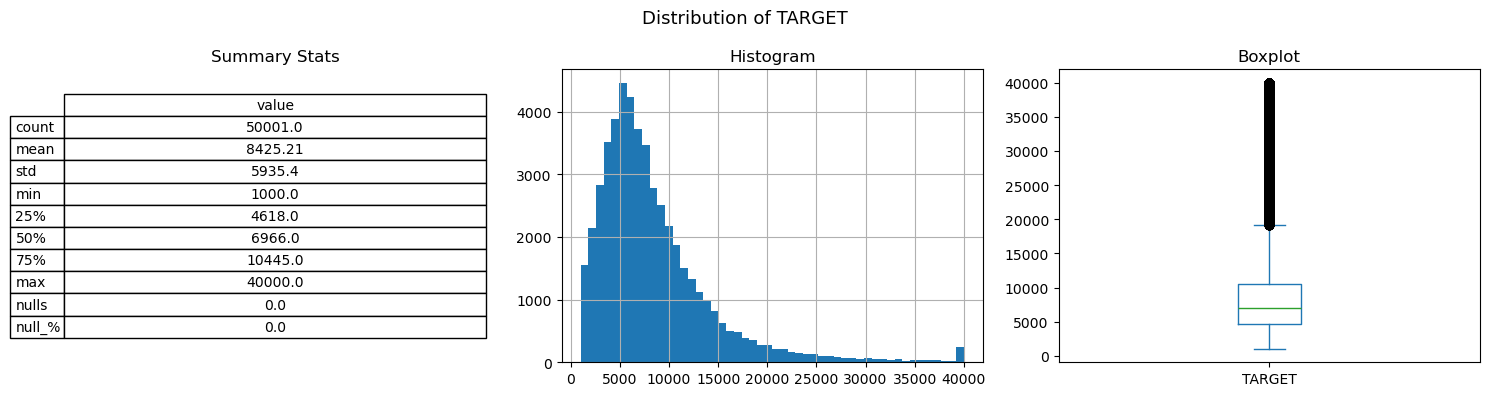

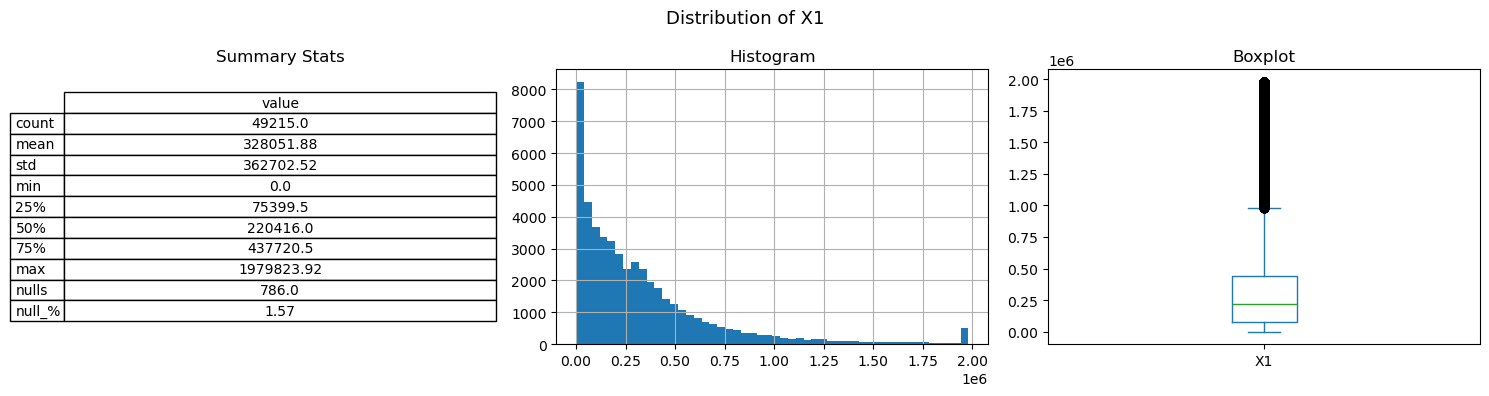

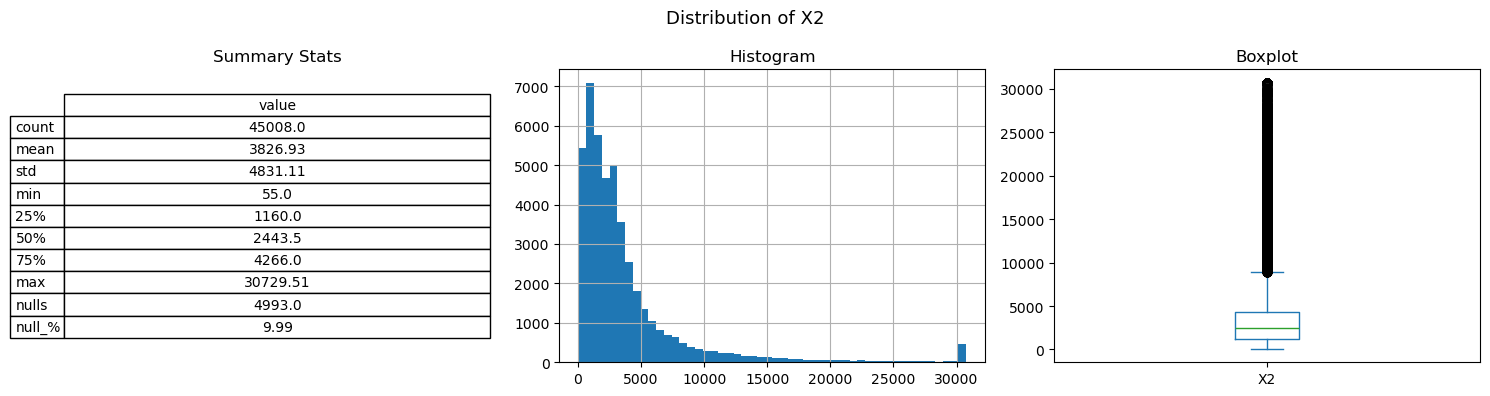

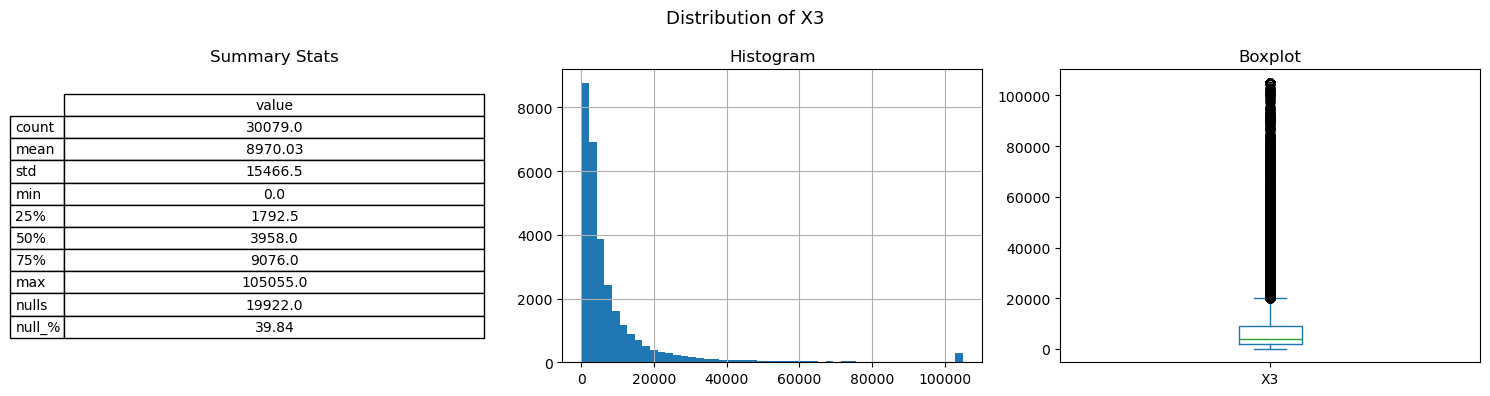

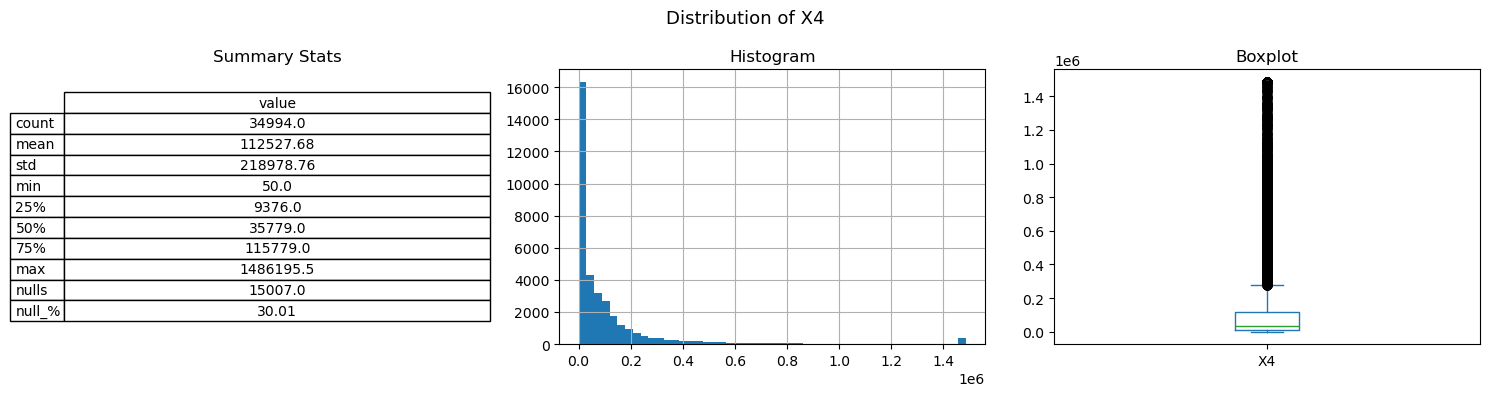

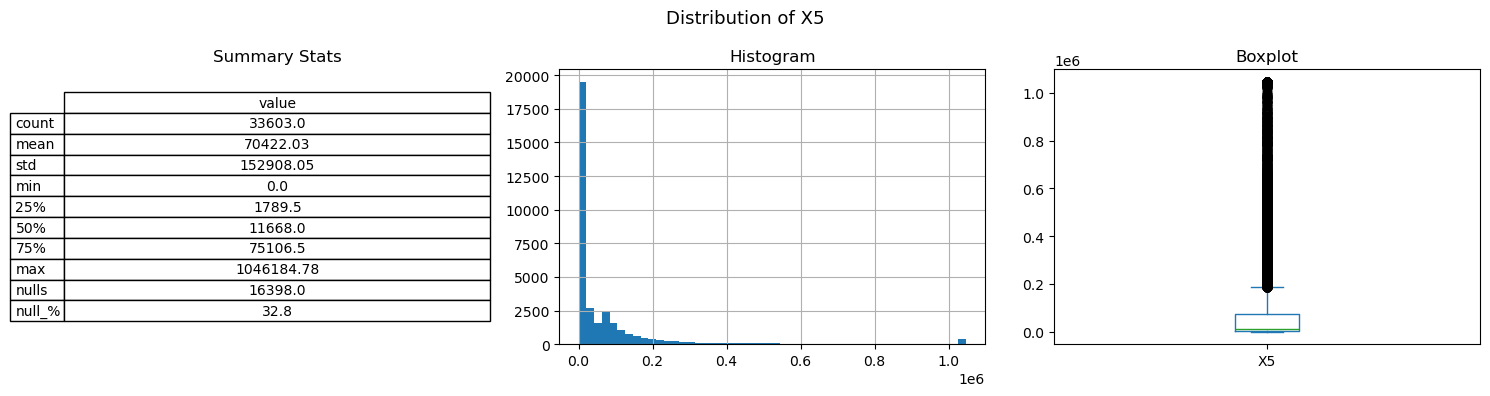

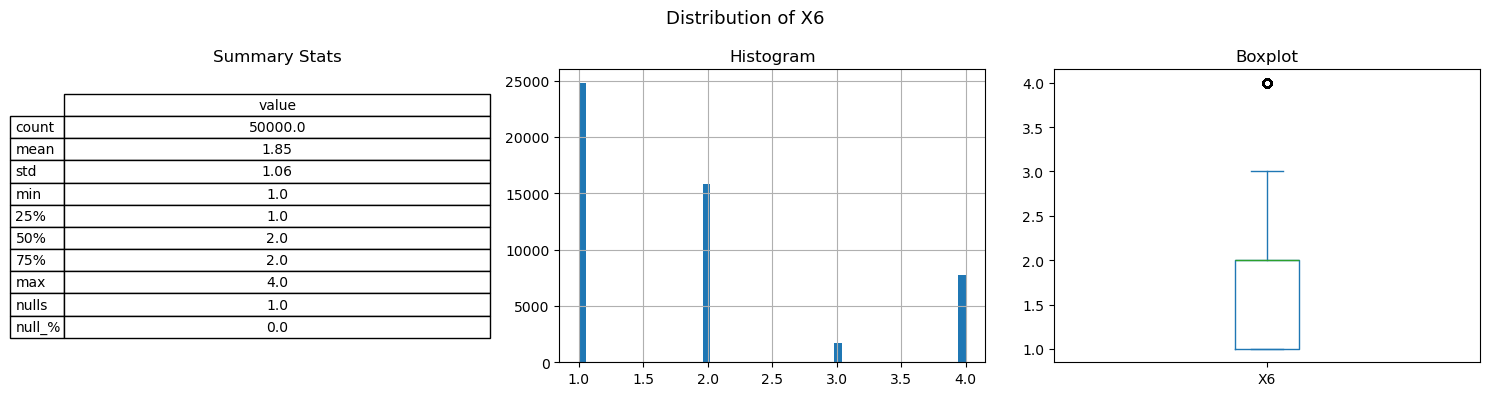

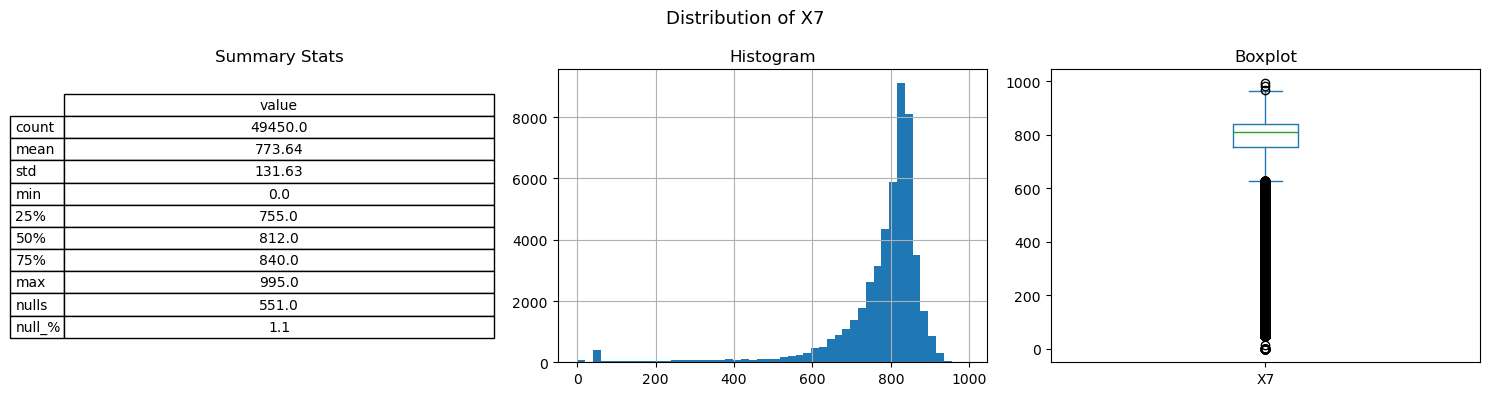

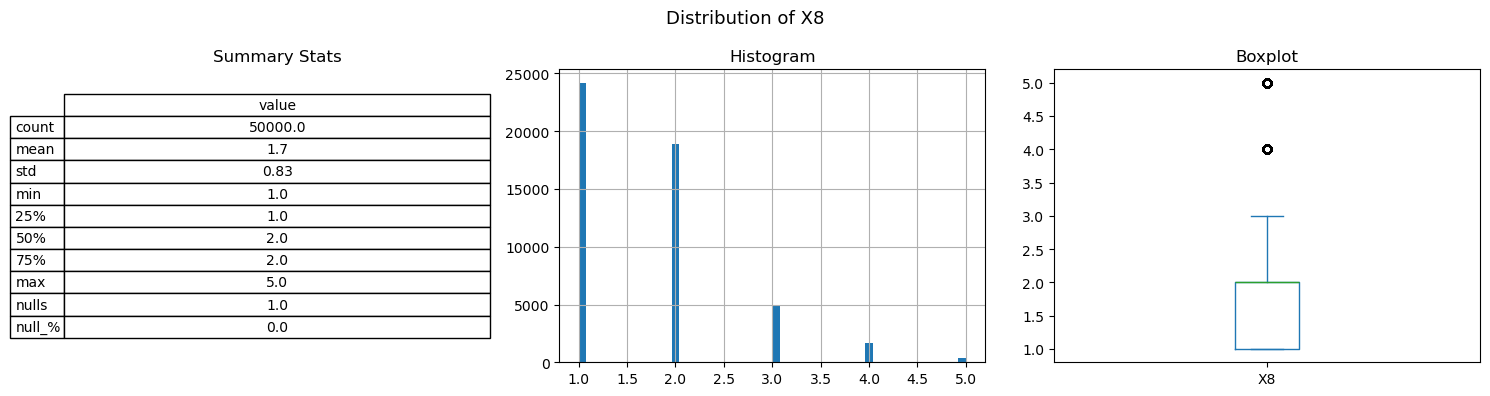

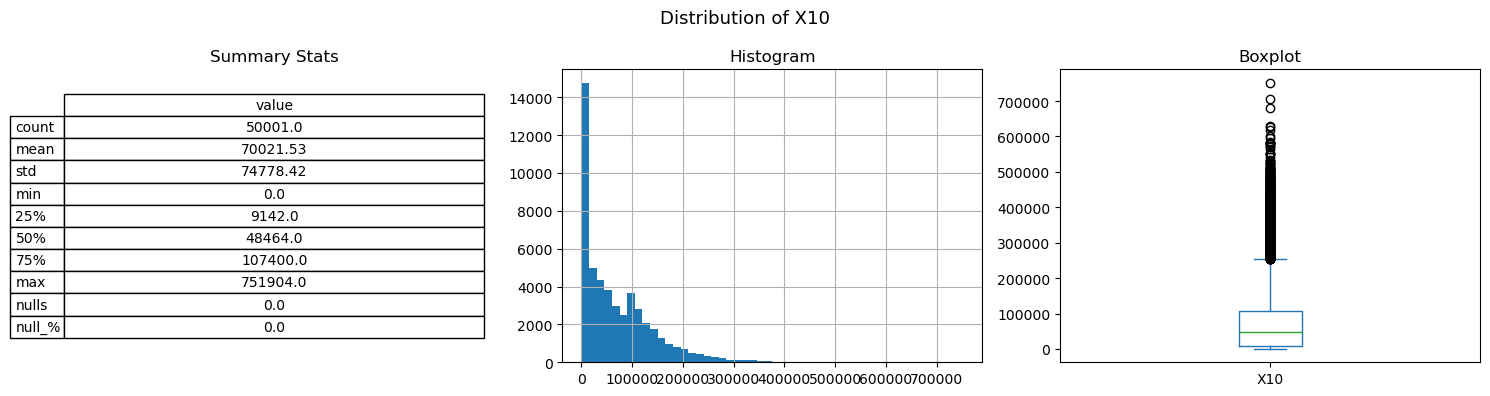

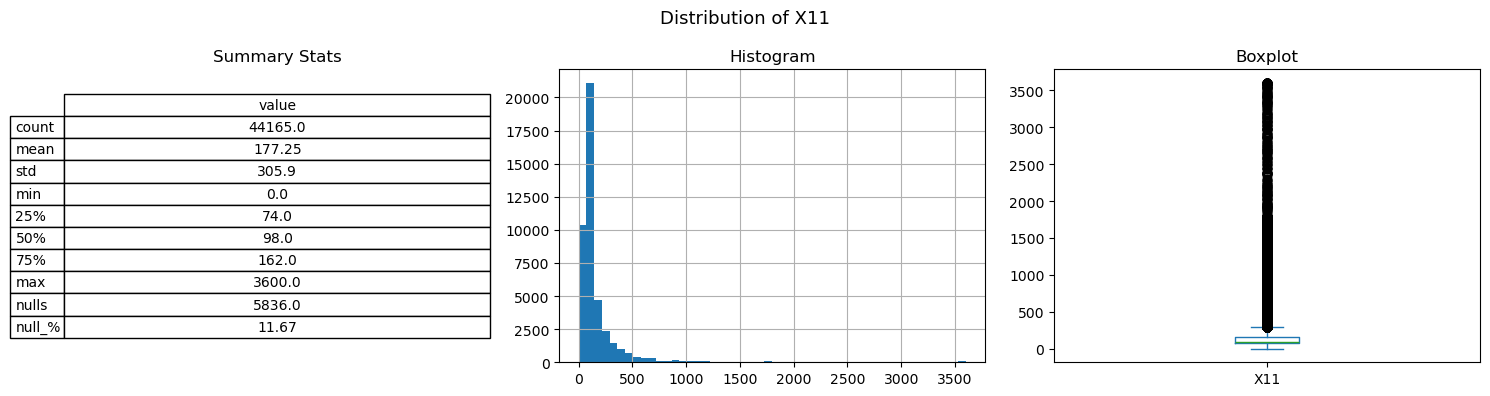

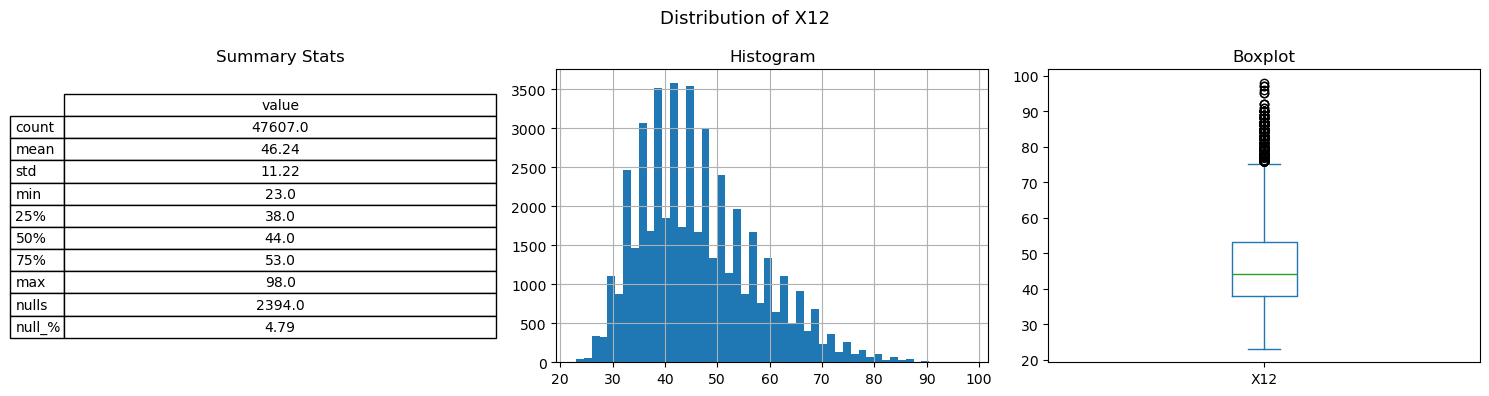

In [13]:
cols_to_cap = ["X1", "X2", "X3", "X4", "X5"]
cols_to_log = ["X1", "X2", "X3", "X4", "X5", "X10", "X11"]

df_capped = df_nosentinels.copy()
# Cap at 99th percentile
for col in cols_to_cap:
    p99 = df_capped[col].quantile(0.99)
    df_capped[col] = df_capped[col].clip(upper=p99)

# Replot
for col in columns:
    plot_distribution(df_capped, col)

## Correlation Analysis

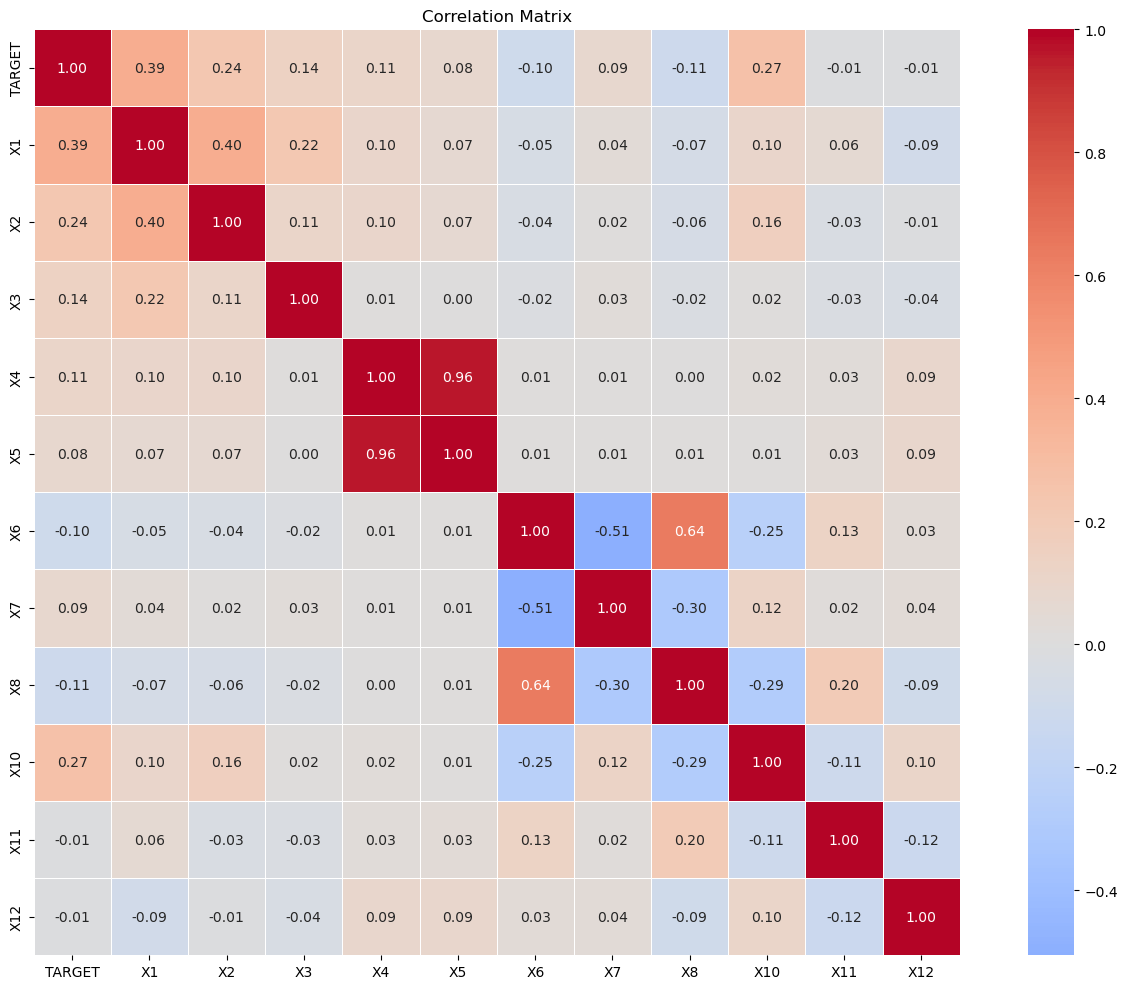

In [14]:
# Correlation matrix — numeric features only, excluding ID and BASE
num_cols = df_nosentinels.select_dtypes(include=np.number).drop(columns=["ID"]).columns

corr = df_nosentinels[num_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, 
            square=True, linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

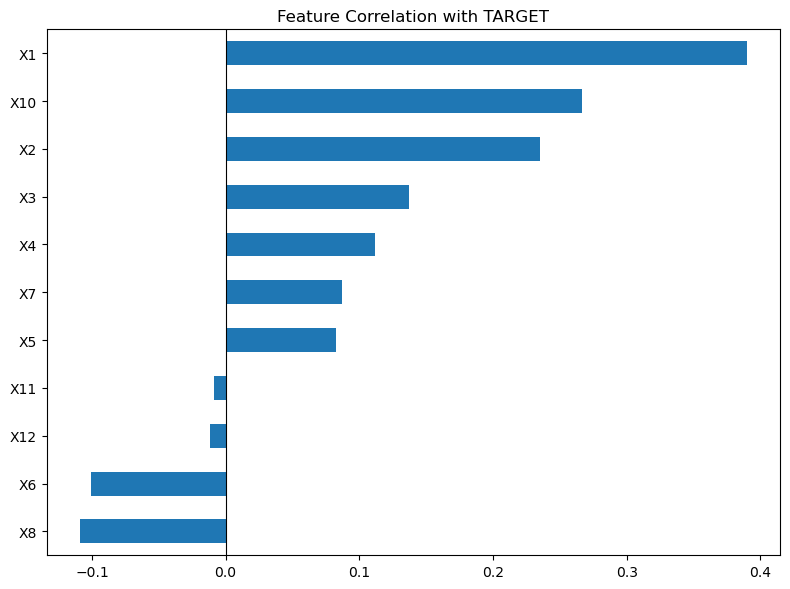

In [15]:
# Correlation with TARGET only — easier to read
corr_target = df_nosentinels[num_cols].corr()["TARGET"].drop("TARGET").sort_values()

corr_target.plot.barh(figsize=(8, 6))
plt.title("Feature Correlation with TARGET")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## Check district distribution

In [20]:
df_nosentinels["X9"].nunique()

630

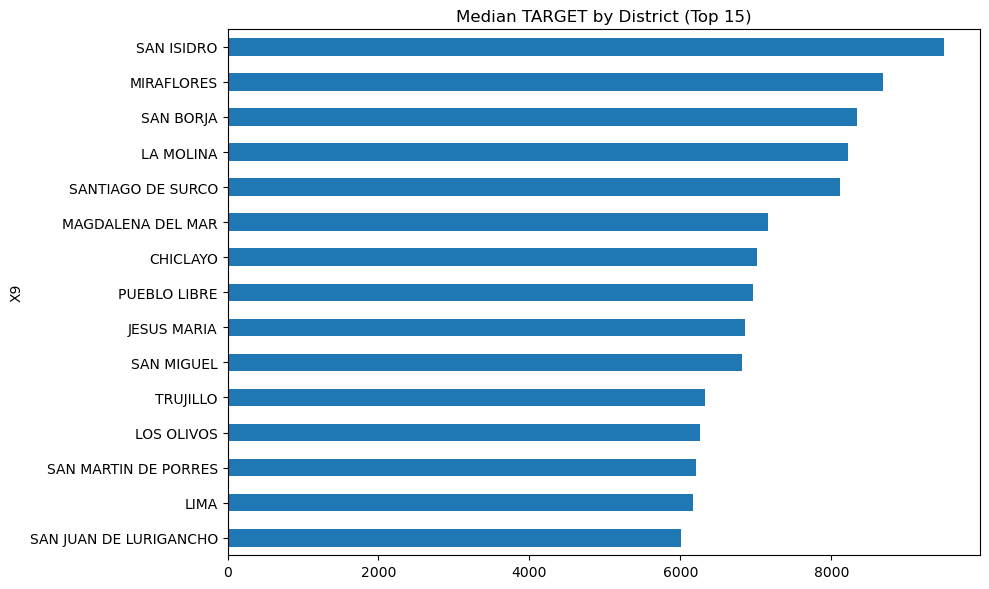

In [17]:
# X9 — TARGET distribution by district (top 15 by frequency)
top_districts = df_nosentinels["X9"].value_counts().head(15).index

df_nosentinels[df_nosentinels["X9"].isin(top_districts)] \
    .groupby("X9")["TARGET"] \
    .median() \
    .sort_values() \
    .plot.barh(figsize=(10, 6))

plt.title("Median TARGET by District (Top 15)")
plt.tight_layout()
plt.show()

## Check split distribution

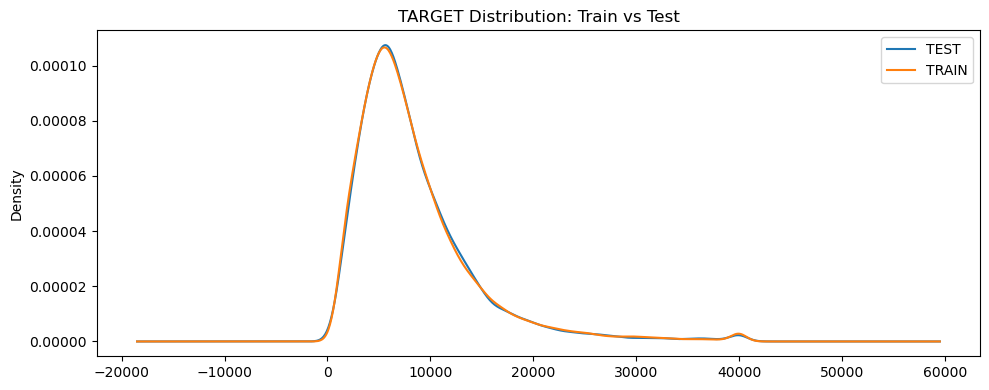

In [18]:
# Train vs Test — TARGET distribution check
df_nosentinels.groupby("BASE")["TARGET"].plot.kde(legend=True, figsize=(10, 4))
plt.title("TARGET Distribution: Train vs Test")
plt.tight_layout()
plt.show()